In [1]:
import numpy as np
import random
import copy
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
import matplotlib.pyplot as plt 
from tqdm import tqdm
import h5py
plt.rcParams['figure.figsize'] =  [3.26, 2]
plt.rcParams.update({'font.size': 6})

from nn_cusum import *
from onnc import *
from onnr import *
docname = "sim1_GaussianMeanShift_stride"
np.random.seed(20240101)


/Users/leviathaniety/Dropbox (GaTech)/PROJ-NeuralNetworkChangePoint/Code/.venv/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Functions

In [2]:
def calculate_EDD(data, maxT, nchange, nrun, ARL):
    # raw data shape: maxT * nrun
    data = np.transpose(data) # nrun * maxT
    
    pre_change_data = data[:, :nchange]
    post_change_data = data[:, nchange:]
    
    max_vals = np.max(pre_change_data, axis=1) # nrun
    ngrid = len(ARL)
    threshold_list = np.zeros(ngrid)
    
    # p = P(max>b)
    hat_p = 1-np.exp((-nchange)/ARL)
    threshold_list = np.quantile(max_vals,1-hat_p)
    
    # EDD
    EDD = np.zeros(ngrid)
    
    for i in range(ngrid):
        threshold = threshold_list[i]
        DD_per_threshold = np.zeros(nrun)
        
        for r in range(nrun):
            try:
                DD_per_threshold[r] = np.argwhere(post_change_data[r] >= threshold)[0]
            except:
                # in case fail to detect since we assume H1 ~ post change dist, max DD should be maxT-nchange
                DD_per_threshold[r] = DD = maxT-nchange
        
        EDD[i] = np.mean(DD_per_threshold) # no std calculation 
        
    return ARL, EDD
    # return ARL, DD_per_threshold


In [3]:
def calculate_EDDList(data, maxT, nchange, nrun, ARL):
    # raw data shape: maxT * nrun
    data = np.transpose(data) # nrun * maxT
    
    pre_change_data = data[:, :nchange]
    post_change_data = data[:, nchange:]
    
    max_vals = np.max(pre_change_data, axis=1) # nrun
    ngrid = len(ARL)
    threshold_list = np.zeros(ngrid)
    
    # p = P(max>b)
    hat_p = 1-np.exp((-nchange)/ARL)
    threshold_list = np.quantile(max_vals,1-hat_p)
    
    # EDD
    EDD = np.zeros(ngrid)
    
    for i in range(ngrid):
        threshold = threshold_list[i]
        DD_per_threshold = np.zeros(nrun)
        
        for r in range(nrun):
            try:
                DD_per_threshold[r] = np.argwhere(post_change_data[r] >= threshold)[0]
            except:
                # in case fail to detect since we assume H1 ~ post change dist, max DD should be maxT-nchange
                DD_per_threshold[r] = DD = maxT-nchange
        
        EDD[i] = np.mean(DD_per_threshold) # no std calculation 
        
    # return ARL, EDD
    return ARL, DD_per_threshold


In [4]:
def test_statistic_new(pilot_X, arrival_Y, stride, tr_window, te_window, batch_size, learning_rate, burnin, nchange,d,
                   use_tr_only=False, use_Xte_window=False):

    # training window parameters
    maxT, dim = arrival_Y.shape
    half_stride = int(stride/2)
    n_fold_tr = int(tr_window/stride) 
    n_fold_te = int(te_window/stride) #number of subwindows in test window
    
    # pilotX, random split training set (to arrive) and test set
    nXpool=pilot_X.shape[0]
    nX_te = int(te_window/2) #effective test window size
    nX_tr = nXpool-nX_te
    samplex_random_idx = random.sample(range(nXpool), nXpool ) 
    X_tr = pilot_X[samplex_random_idx[:nX_tr],:] # train
    X_te = pilot_X[samplex_random_idx[nX_tr:nX_tr+nX_te] ,:] # test
    
    # init model
    num_neurons = 64
    model = nn_one_hidden_layer(dim, num_neurons, 1) #init model
 
    model_init_params = copy.deepcopy(model.state_dict())

    # optimization parameter
    # print("learning rate: {}".format(learning_rate))
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)    
    
    #storage of training statistics, average on testing window
    mXt, mYt = np.zeros(maxT), np.zeros(maxT) #window averaged test statistic
    Wprevr =0
    dWt, Wt = np.zeros(maxT), np.zeros(maxT) #CUSUM

    model.train()
    model.load_state_dict(model_init_params)

    # tr_window and tr_window_lag
    wtr_len = 0 #the record of window len 
    dataX_wtr = np.float32( np.zeros( (n_fold_tr*half_stride,dim) ))
    dataY_wtr = np.float32( np.zeros( (n_fold_tr*half_stride,dim) ))

    wtr_lag_len =0
    dataX_wtr_lag = np.float32( np.zeros( (n_fold_tr*half_stride,dim) ))
    dataY_wtr_lag = np.float32( np.zeros( (n_fold_tr*half_stride,dim) ))

    wte_len = 0
    dataX_wte = np.float32( np.zeros( (n_fold_te*half_stride,dim) ))
    dataY_wte = np.float32( np.zeros( (n_fold_te*half_stride,dim) )) 
    #not used for testing, just go together with Yte_window

    i= 0 #index of actual time
    train_loop_count = 0

    while i <= maxT-stride:
        #load the train split of minibatch of data
        miniX_tr = X_tr[(np.mod(range(i,i+half_stride),nX_tr)),:] #loope over X_tr
        miniY_tr = arrival_Y[i:i+half_stride,:] 
        # hit the model with minibatch of training samples
        train_miniwindow(miniX_tr, miniY_tr, model, optimizer)

        # update training window
        if wtr_len < tr_window/2:
            augment_window_update(dataX_wtr, wtr_len, miniX_tr)
            augment_window_update(dataY_wtr, wtr_len, miniX_tr)
            wtr_len=wtr_len+half_stride                
            Xtr_exist =dataX_wtr[:wtr_len,:]
            Ytr_exist =dataY_wtr[:wtr_len,:]
            train_loop(Xtr_exist, Ytr_exist, model, optimizer, batch_size)  
        else: #training window is full
            # first train the model with existing batches
            # only retrain at increment of opt_batch_size
            if use_tr_only:
                Xtr_exist =dataX_wtr[:wtr_len,:]
                Ytr_exist =dataY_wtr[:wtr_len,:]
            else:
                Xtr_exist =np.concatenate((dataX_wtr[:wtr_len,:], dataX_wtr_lag[:wtr_lag_len]),axis=0)
                Ytr_exist =np.concatenate((dataY_wtr[:wtr_len,:], dataY_wtr_lag[:wtr_lag_len]),axis=0)
            
            if Xtr_exist.shape[0] > 0:
                train_loop_count += 1
                train_loop(Xtr_exist, Ytr_exist, model, optimizer, batch_size)  
            #train loop over the exising training stack, including training window and lag training window
            # shift and update training window
            shift_window_update(dataX_wtr,miniX_tr)
            shift_window_update(dataY_wtr,miniY_tr)

        #load the test split of minibatch of data
        miniX_te =X_tr[(np.mod(range(i+half_stride,i+stride),nX_tr)),:]
        miniY_te =arrival_Y[i+half_stride:i+stride,:]
    
        # update test window
        if wte_len < te_window/2:
            # put into test window
            augment_window_update(dataX_wte, wte_len, miniX_te)
            augment_window_update(dataY_wte, wte_len, miniY_te)
            wte_len=wte_len+half_stride
        else: #if a test window is full
            if wtr_lag_len < tr_window/2:
                augment_window_update(dataX_wtr_lag, wtr_lag_len, dataX_wte[0:half_stride,:])
                augment_window_update(dataY_wtr_lag, wtr_lag_len, dataY_wte[0:half_stride,:])
                wtr_lag_len=wtr_lag_len+half_stride
            else:
                # shift a stride fwd in the training lag window
                shift_window_update(dataX_wtr_lag,dataX_wte[0:half_stride,:])
                shift_window_update(dataY_wtr_lag,dataY_wte[0:half_stride,:])         
            # shift a stride fwd of test sindow
            shift_window_update(dataX_wte,miniX_te)
            shift_window_update(dataY_wte,miniY_te)

        # deploy the model on the test window
        with torch.no_grad():
            dataY_te=dataY_wte[:wte_len,:]
            uY = model(torch.tensor(dataY_te))
            uYmean = uY.reshape(-1).numpy().mean()
            mYt[i+stride-1] = uYmean
            if use_Xte_window:
                dataX_te=dataX_wte[:wte_len,:]
            else:
                dataX_te= X_te #though data is the same X_te, the model differs, recompute uX each step
            uX = model(torch.tensor(dataX_te)) 
            uXmean = uX.reshape(-1).numpy().mean()
            mXt[i+stride-1] = uXmean

        # recursive CUSUM
        eta_stride=uYmean-uXmean
        dWt[i+stride-1] = eta_stride
        d = d
        if i+stride == nchange:
            Wt[i+stride-1] = 0
        elif i+stride == burnin:
            Wt[i+stride-1] = 0
        else: 
            Wt[i+stride-1] = max(0, eta_stride+Wprevr-d)
            # Wt[i+stride-1] = eta_stride
        Wprevr = Wt[i+stride-1]

        #increase the batch index, and sample index i    
        i = i+stride
    
    idx = range(stride-1, maxT, stride) 
    Wt = Wt[idx]
    dWt = dWt[idx]
    mXt = mXt[idx]
    mYt = mYt[idx]
    # print("train_loop_count: {}".format(train_loop_count))
    return idx, Wt, dWt, model, mXt, mYt #, model

### Data generation

In [5]:
# high dimensional gaussian mean shift
def gen_mean_shift_P(dim,maxT):
    mu_mx = np.zeros(dim)
    sigma_mx = np.identity(dim)
    X = np.random.multivariate_normal(mu_mx, sigma_mx, maxT)
    return np.float32(X)

def gen_mean_shift_Q(dim,maxT,delta):
    mu_mx = np.zeros(dim)
    for i in range(min(dim,3)):
            mu_mx[i] = delta/(i+1)
    sigma_mx = np.identity(dim)
    X = np.random.multivariate_normal(mu_mx, sigma_mx, maxT)
    return np.float32(X)

# Implementation

In [11]:
nrun = 10
dim = 100 #50 #2
nXpool, maxT, nchange = 15000, 10500, 5500
stride = 10
tr_window = 100 # 100 #stack of training window
te_window = 100
burnin = 5000
# simulate data
deltaList = [0.1]

In [12]:
for i in range(1):
    delta = deltaList[i]
    Xarr = np.zeros((nrun,nXpool,dim))
    Yarr = np.zeros((nrun,maxT,dim))
    for irun in tqdm(range(nrun)):
        # generate data
        X = gen_mean_shift_P(dim, nXpool) # P shape = (T,dim)
        X = X[torch.randperm(nXpool).numpy(),:]

        Ynull = gen_mean_shift_P(dim, nchange) #P
        Ynull = Ynull[torch.randperm(nchange).numpy(),:]

        Y = gen_mean_shift_Q(dim, maxT-nchange, delta) #Q
        Y = Y[torch.randperm(maxT-nchange).numpy(),:]
        
        Xarr[irun] = np.float32(X) #the pool, theoretically, the pool is even larger
        Yarr[irun] = np.float32(np.concatenate( (Ynull, Y), axis=0)) #arrival data Y
    # np.save(docname+'Delta'+str(delta)+'Dim'+str(dim)+'Xarr.npy',Xarr) # prerun knowledge for pre-change
    # np.save(docname+'Delta'+str(delta)+'Dim'+str(dim)+'Yarr.npy',Yarr) # simulated data

100%|██████████| 10/10 [00:01<00:00,  9.22it/s]


Tune drift d

In [7]:
ntune = 500
dW_nn_pre = np.zeros( [nXpool,ntune])
dList = np.zeros(ntune)

In [72]:
for i in range(1):
    delta = deltaList[i]

    for irun in tqdm(range(ntune)):
        pilot_X = gen_mean_shift_P(dim, nXpool) # P shape = (T,dim)
        pilot_X = pilot_X[torch.randperm(nXpool).numpy(),:]
        Ynull = gen_mean_shift_P(dim, nchange) #P
        Ynull = Ynull[torch.randperm(nchange).numpy(),:]

        idxt_nn = range(stride-1,nchange,stride)
        idxt_post_burnin = range(burnin+stride-1,nchange,stride)

        # nn cusum
        # nn parameter
        # print('NN CUSUM start')
        stride = 10
        # neural network optimization parameter
        opt_batch_size = 100 # small for easy task, large for hard task
            #when opt_bs is too large, instability in training
            #when too small, too many effective loops, also larger variance
        effective_epoch = int( tr_window/(opt_batch_size*2)) #about 5~10
        use_tr_only = False #default is False, if false, use both training window and trainig lag window
                        #if true, only use training minibatch, not training lag
        use_Xte_window = True #if true, use "arrival mode" of p samples. 
                            #if false, use fixed X_te from pilot pool 

        tmp_idxt_nn,Wt_nn,dWt_nn,model,mXt_nn,mYt_nn = test_statistic_new(pilot_X, Ynull, stride, tr_window, te_window, opt_batch_size,0.002,burnin,nchange,0,
                                            use_tr_only, use_Xte_window)
        dW_nn_pre[idxt_nn,irun]=dWt_nn
        dList[irun] = np.mean(dW_nn_pre[idxt_post_burnin,irun])

        

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [08:29<00:00,  1.02s/it]


In [8]:
d = np.mean(dList)
d, np.std(dList)

(0.0, 0.0)

Compare

  0%|          | 0/10 [00:00<?, ?it/s]

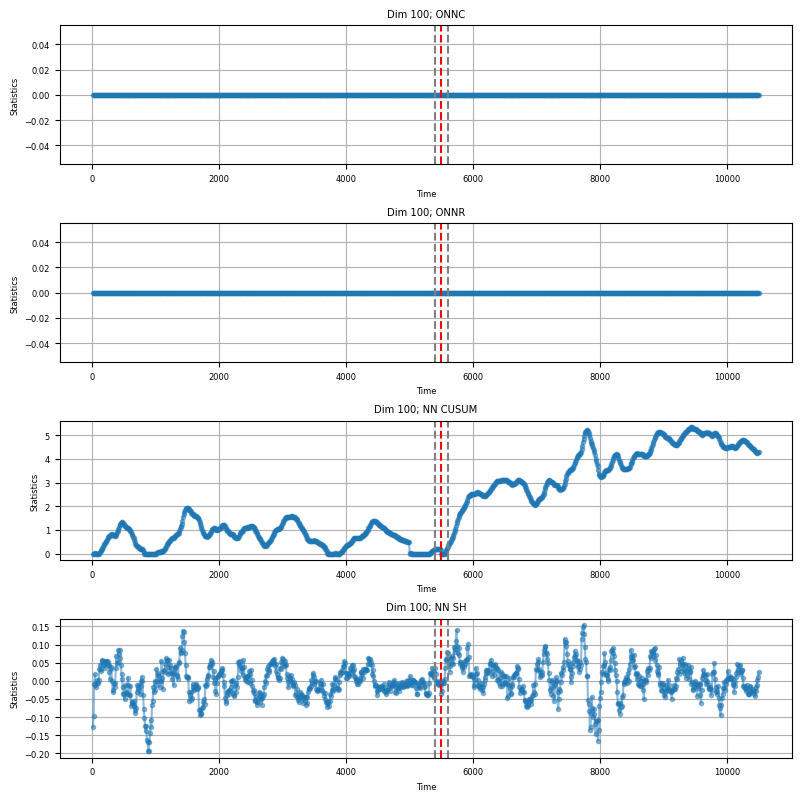

 10%|█         | 1/10 [00:02<00:20,  2.24s/it]

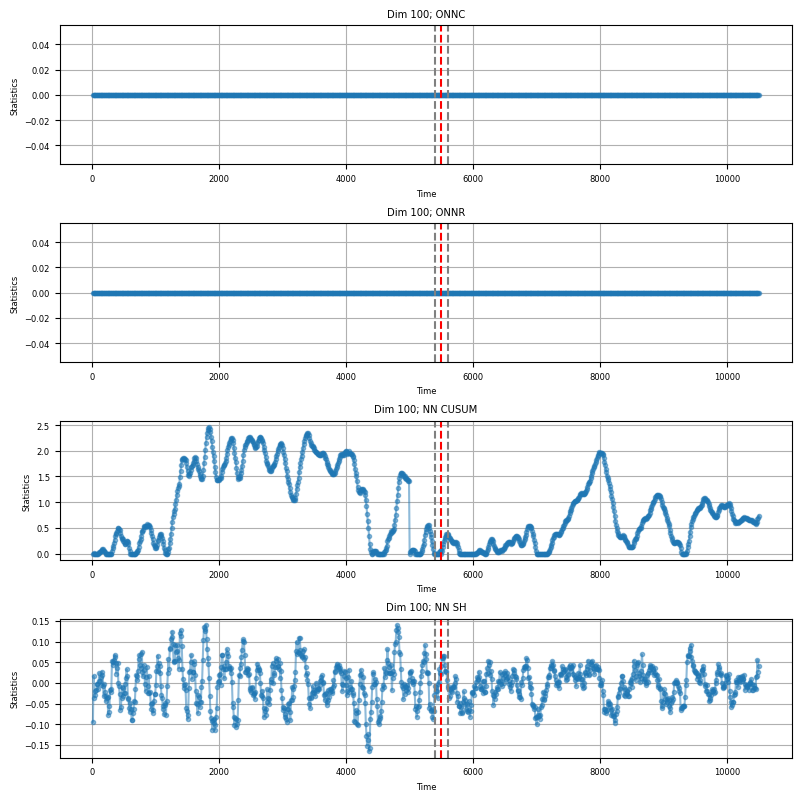

 20%|██        | 2/10 [00:04<00:16,  2.02s/it]

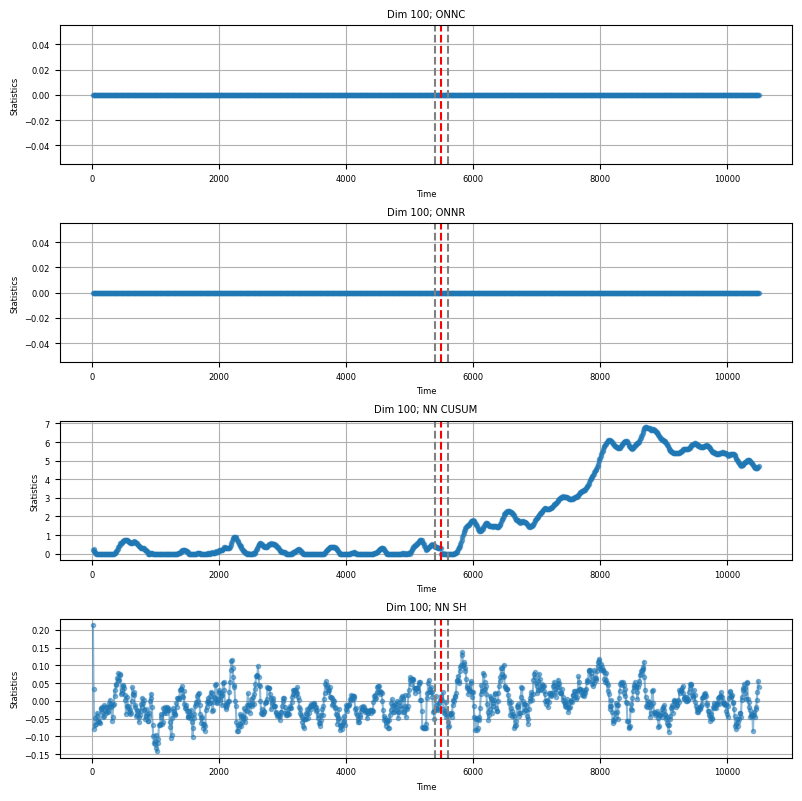

 30%|███       | 3/10 [00:06<00:14,  2.07s/it]

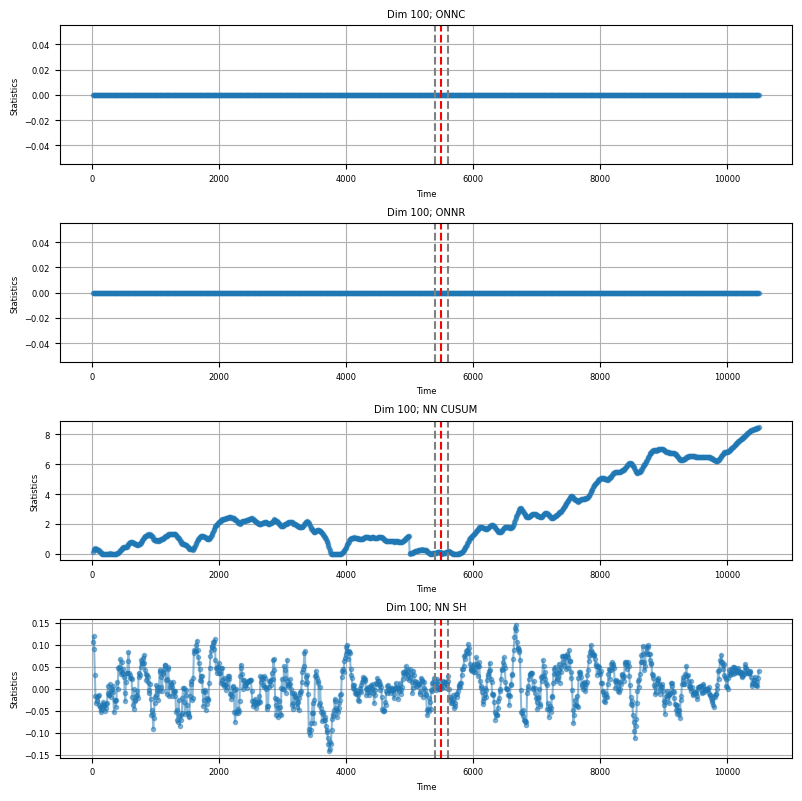

100%|██████████| 10/10 [00:18<00:00,  1.86s/it]


In [13]:
W_nn = np.zeros( [maxT,nrun])
W_nnsh = np.zeros( [maxT,nrun])
W_onnc = np.zeros( [maxT,nrun])
W_onnr = np.zeros( [maxT,nrun])


for i in range(1):
    delta = deltaList[i]
    # Xarr = np.load(docname+'Delta'+str(delta)+'Dim'+str(dim)+'Xarr.npy')
    # Yarr = np.load(docname+'Delta'+str(delta)+'Dim'+str(dim)+'Yarr.npy')

    for irun in tqdm(range(nrun)):
        pilot_X = np.float32(Xarr[irun]) #the pool, theoretically, the pool is even larger
        pre_Y = np.float32(Yarr[irun,burnin:nchange]) #arrival data Y
        post_Y = np.float32(Yarr[irun,nchange:]) #arrival data Y

        idxt = range(maxT)
        preidxt = range(nchange)
        postidxt = range(nchange, maxT)
        idxt_nn = range(stride-1,maxT,stride)

        # nn cusum
        # nn parameter
        # print('NN CUSUM start')
        stride = 10
        # neural network optimization parameter
        opt_batch_size = 100
            #when opt_bs is too large, instability in training
            #when too small, too many effective loops, also larger variance
        effective_epoch = int( tr_window/(opt_batch_size*2)) #about 5~10
        use_tr_only = False #default is False, if false, use both training window and trainig lag window
                        #if true, only use training minibatch, not training lag
        use_Xte_window = True #if true, use "arrival mode" of p samples. 
                            #if false, use fixed X_te from pilot pool 

        tmp_idxt_nn,Wt_nn,dWt_nn,model,mXt_nn,mYt_nn = test_statistic_new(pilot_X, np.float32(Yarr[irun,:]), stride, tr_window, te_window, opt_batch_size,0.002,burnin,nchange,d,
                                            use_tr_only, use_Xte_window)
        W_nn[idxt_nn,irun]=Wt_nn
        W_nnsh[idxt_nn,irun]=dWt_nn


        # onnc
        # print('ONNC start')
        # neural network optimization parameter

        # Wt_onnc, _ = onnc_statistic_stride(pilot_X, Yarr[irun], 'one_hidden', 64, stride, te_window//2, 0.002, 1)
        # W_onnc[idxt,irun]=Wt_onnc


        # onnr
        # print('ONNR start')
        # neural network optimization parameter

        # Wt_onnr, _ = onnr_statistic_stride(pilot_X, Yarr[irun], 'one_hidden', 64, 0.1, stride, te_window//2, 0.002, 1)
        # W_onnr[idxt,irun]=Wt_onnr


        if irun < 4:
            fig = plt.figure(figsize= (8,8))

            plt.subplot(411)
            plt.plot(idxt_nn, W_onnc[idxt_nn,irun],'.-', alpha = 0.5, label='Wt')
            plt.axvline(x=nchange-te_window, linestyle="--", color="grey")
            plt.axvline(x=nchange, linestyle="--", color="red")
            plt.axvline(x=nchange+te_window, linestyle="--", color="grey")
            plt.grid()
            plt.xlabel('Time')
            plt.ylabel('Statistics')
            plt.title(f'Dim {dim:>d}; ONNC')

            plt.subplot(412)
            plt.plot(idxt_nn, W_onnr[idxt_nn,irun],'.-', alpha = 0.5, label='Wt')
            plt.axvline(x=nchange-te_window, linestyle="--", color="grey")
            plt.axvline(x=nchange, linestyle="--", color="red")
            plt.axvline(x=nchange+te_window, linestyle="--", color="grey")
            plt.grid()
            plt.xlabel('Time')
            plt.ylabel('Statistics')
            plt.title(f'Dim {dim:>d}; ONNR')

            plt.subplot(413)
            plt.plot(idxt_nn,W_nn[idxt_nn,irun],'.-', alpha = 0.5, label='Wt')
            plt.axvline(x=nchange-te_window, linestyle="--", color="grey")
            plt.axvline(x=nchange, linestyle="--", color="red")
            plt.axvline(x=nchange+te_window, linestyle="--", color="grey")
            plt.grid()
            plt.xlabel('Time')
            plt.ylabel('Statistics')
            plt.title(f'Dim {dim:>d}; NN CUSUM')

            plt.subplot(414)
            plt.plot(idxt_nn,W_nnsh[idxt_nn,irun],'.-', alpha = 0.5, label='Wt')
            plt.axvline(x=nchange-te_window, linestyle="--", color="grey")
            plt.axvline(x=nchange, linestyle="--", color="red")
            plt.axvline(x=nchange+te_window, linestyle="--", color="grey")
            plt.grid()
            plt.xlabel('Time')
            plt.ylabel('Statistics')
            plt.title(f'Dim {dim:>d}; NN SH')
            plt.tight_layout()
            plt.show()





In [75]:
hf = h5py.File(docname+'Delta'+str(delta)+'Dim'+str(dim), 'w')
hf.create_dataset('dList', data=dList, dtype=np.float32)
hf.create_dataset('Wnn', data=W_nn, dtype=np.float32)
hf.create_dataset('Wnnsh', data=W_nnsh, dtype=np.float32)
hf.create_dataset('Wonnc', data=W_onnc, dtype=np.float32)
hf.create_dataset('Wonnr', data=W_onnr, dtype=np.float32)
hf.close()

# ARL-EDD

In [5]:
delta = deltaList[0]
with h5py.File(docname+'Delta'+str(delta)+'Dim'+str(dim), "r") as f:
    dList = f["dList"][()]
    W_nn = f["Wnn"][()]
    W_nnsh = f["Wnnsh"][()]
    W_onnc = f["Wonnc"][()]
    W_onnr = f["Wonnr"][()]
    f.close()

In [6]:
W_nnsh.shape

(10500, 400)

In [24]:
idxt_burnin_nchange = range(burnin+stride-1,nchange,stride)
idxt_nchange_maxT = range(nchange+stride-1,maxT,stride)
incre_pre = W_nnsh[idxt_burnin_nchange,:]
incre_post = W_nnsh[idxt_nchange_maxT,:]


tmp = np.zeros((3,2))
tmp[0,:] = np.mean(dList), np.std(dList)
tmp_pre = np.mean(incre_pre,0)
tmp[1,:] = np.mean(tmp_pre), np.std(tmp_pre)
tmp_post = np.mean(incre_post,0)
tmp[2,:] = np.mean(tmp_post), np.std(tmp_post)

In [25]:
tmp = tmp*1e4
print(str(round(tmp[0,0],2))+" ("+ str(round(tmp[0,1],3))+")")
print(str(round(tmp[1,0],2))+" ("+ str(round(tmp[1,1],3))+")")
print(str(round(tmp[2,0],2))+" ("+ str(round(tmp[2,1],3))+")")

-7.81 (155.042)
3.65 (146.189)
40.59 (55.647)


In [8]:
ARL_nn = 10**(np.arange(2,5.6,0.1))
ARL_d05_nn, EDD_d05_nn = calculate_EDD(W_nn[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_nnsh, EDD_d05_nnsh = calculate_EDD(W_nnsh[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_wonnc, EDD_d05_wonnc = calculate_EDD(W_onnc[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_wonnr, EDD_d05_wonnr = calculate_EDD(W_onnr[burnin:,:], 5500, 500, nrun, ARL_nn)

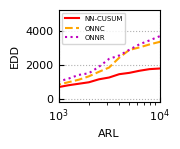

In [15]:
# plotting
plt.rcParams['figure.figsize'] =  [3.26*2/5, 6/5]
plt.rcParams.update({'font.size': 8})
plt.tight_layout()
plt.plot((ARL_d05_nn), EDD_d05_nn, label="NN-CUSUM", color="red")
plt.plot((ARL_d05_wonnc), EDD_d05_wonnc, label="ONNC",c='orange',linestyle = '--')
plt.plot((ARL_d05_wonnr), EDD_d05_wonnr, label="ONNR",c='m',linestyle = ':')

plt.xlim(10**3, 10**4)
plt.xscale('log')
plt.tick_params(direction="in")
plt.grid(linestyle="dotted")
plt.xlabel("ARL")
plt.ylabel("EDD")
plt.legend(loc='best',ncol=1, fontsize=5)
plt.savefig('plots/'+docname+'Delta'+str(delta)+'Dim'+str(dim)+'.pdf', bbox_inches = 'tight',pad_inches=0.0)

In [25]:
delta

0.1

In [13]:
ARL_nn = np.array([5000])
ARL_d05_nn, EDD_d05_nn = calculate_EDDList(W_nn[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_nnsh, EDD_d05_nnsh = calculate_EDDList(W_nnsh[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_wonnc, EDD_d05_wonnc = calculate_EDDList(W_onnc[burnin:,:], 5500, 500, nrun, ARL_nn)
ARL_d05_wonnr, EDD_d05_wonnr = calculate_EDDList(W_onnr[burnin:,:], 5500, 500, nrun, ARL_nn)

In [16]:
print(str(round(np.mean(EDD_d05_nn),2))+" ("+ str(round(np.std(EDD_d05_nn)/np.sqrt(nrun),3))+")")
print(str(round(np.mean(EDD_d05_wonnc),2))+" ("+ str(round(np.std(EDD_d05_wonnc)/np.sqrt(nrun),3))+")")
print(str(round(np.mean(EDD_d05_wonnr),2))+" ("+ str(round(np.std(EDD_d05_wonnr)/np.sqrt(nrun),3))+")")

1520.31 (54.474)
2863.52 (85.842)
2869.97 (87.977)
